In [1]:
import subprocess, sys
required = ["opencv-python", "scikit-image", "scipy", "pandas", "numpy", "matplotlib"]
for pkg in required:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], capture_output=True)

import cv2, os, glob, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import skew, kurtosis
from IPython.display import display
warnings.filterwarnings('ignore')
print('✔ Import selesai')

✔ Import selesai


## Cell 2 — Konfigurasi Path & Parameter

In [2]:
IMG_DIR      = r"C:\Users\Yohanes\OneDrive\Documents\COLLEGE\8th Semester\Tugas Akhir\Software\Jupyter\Nyoba\Chula-RBC-12-Dataset-main\Dataset"
TXT_DIR      = r"C:\Users\Yohanes\OneDrive\Documents\COLLEGE\8th Semester\Tugas Akhir\Software\Jupyter\Nyoba\Chula-RBC-12-Dataset-main\Label"
REF_IMG_PATH = r"C:\Users\Yohanes\OneDrive\Documents\COLLEGE\8th Semester\Tugas Akhir\Result\1_Preprocessing\63365.png"
OUTPUT_DIR   = r"C:\Users\Yohanes\OneDrive\Documents\COLLEGE\8th Semester\Tugas Akhir\Result\3_Ekstraksi Fitur"

# ── Crop: tetap 80×80 (HALF=40) supaya kontur sel tidak terpotong
CROP_SIZE = 40
HALF      = CROP_SIZE // 2

# ── Label IDA sesuai konsultasi klinis
IDA_LABELS = [2, 5, 6, 10, 11, 12]

N_SAMPLE    = 4
RANDOM_SEED = 42

NAMA_LABEL = {
    0: "Normal RBC",  1: "Macrocyte",   2: "Microcyte",
    3: "Spherocyte",  4: "Target Cell", 5: "Stomatocyte",
    6: "Ovalocyte",   7: "Teardrop",    8: "Burr Cell",
    9: "Schistocyte", 10: "Other",      11: "Hypochromic",
    12: "Elliptocyte"
}

txt_files = sorted(glob.glob(os.path.join(TXT_DIR, "*.txt")))
img_files = []
for ext in ["*.jpg", "*.png", "*.jpeg"]:
    img_files += glob.glob(os.path.join(IMG_DIR, ext))
img_files = sorted(img_files)

print(f"IMG_DIR    : {IMG_DIR}")
print(f"TXT_DIR    : {TXT_DIR}")
print(f"OUTPUT_DIR : {OUTPUT_DIR}")
print(f"\nFile gambar : {len(img_files)}")
print(f"File TXT    : {len(txt_files)}")

if txt_files:
    total_sel, label_count = 0, {}
    for t in txt_files:
        with open(t) as f:
            for line in f:
                d = line.strip().split()
                if len(d) >= 3:
                    total_sel += 1
                    lbl = int(d[2])
                    label_count[lbl] = label_count.get(lbl, 0) + 1
    print(f"Total sel   : {total_sel:,}")
    print(f"\nDistribusi label:")
    for lbl in sorted(label_count):
        pct  = label_count[lbl] / total_sel * 100
        nama = NAMA_LABEL.get(lbl, "?")
        tag  = " ← IDA" if lbl in IDA_LABELS else ""
        print(f"  L{lbl:2d} ({nama:15s}): {label_count[lbl]:5,} ({pct:5.1f}%){tag}")
print("\n✔ Konfigurasi selesai")

IMG_DIR    : C:\Users\Yohanes\OneDrive\Documents\COLLEGE\8th Semester\Tugas Akhir\Software\Jupyter\Nyoba\Chula-RBC-12-Dataset-main\Dataset
TXT_DIR    : C:\Users\Yohanes\OneDrive\Documents\COLLEGE\8th Semester\Tugas Akhir\Software\Jupyter\Nyoba\Chula-RBC-12-Dataset-main\Label
OUTPUT_DIR : C:\Users\Yohanes\OneDrive\Documents\COLLEGE\8th Semester\Tugas Akhir\Result\3_Ekstraksi Fitur

File gambar : 738
File TXT    : 623
Total sel   : 22,106

Distribusi label:
  L 0 (Normal RBC     ): 6,330 ( 28.6%)
  L 1 (Macrocyte      ):   689 (  3.1%)
  L 2 (Microcyte      ):   461 (  2.1%) ← IDA
  L 3 (Spherocyte     ): 3,449 ( 15.6%)
  L 4 (Target Cell    ): 2,753 ( 12.5%)
  L 5 (Stomatocyte    ): 1,996 (  9.0%) ← IDA
  L 6 (Ovalocyte      ): 2,140 (  9.7%) ← IDA
  L 7 (Teardrop       ):   307 (  1.4%)
  L 8 (Burr Cell      ):   785 (  3.6%)
  L 9 (Schistocyte    ):   897 (  4.1%)
  L10 (Other          ):   184 (  0.8%) ← IDA
  L11 (Hypochromic    ): 1,063 (  4.8%) ← IDA
  L12 (Elliptocyte    ): 1,052

## Cell 3 — Preprocessing (sesuai Das et al. IEEE TCYB 2022)
Pipeline: Median Filter → Reinhard Normalization → CLAHE → LoG Highboosting

**LoG parameters (Eq. 1 & 2 paper):** σ=1.0, kernel 7×7, k=1.5, formula: `FI = CI + k·LG(CI)`

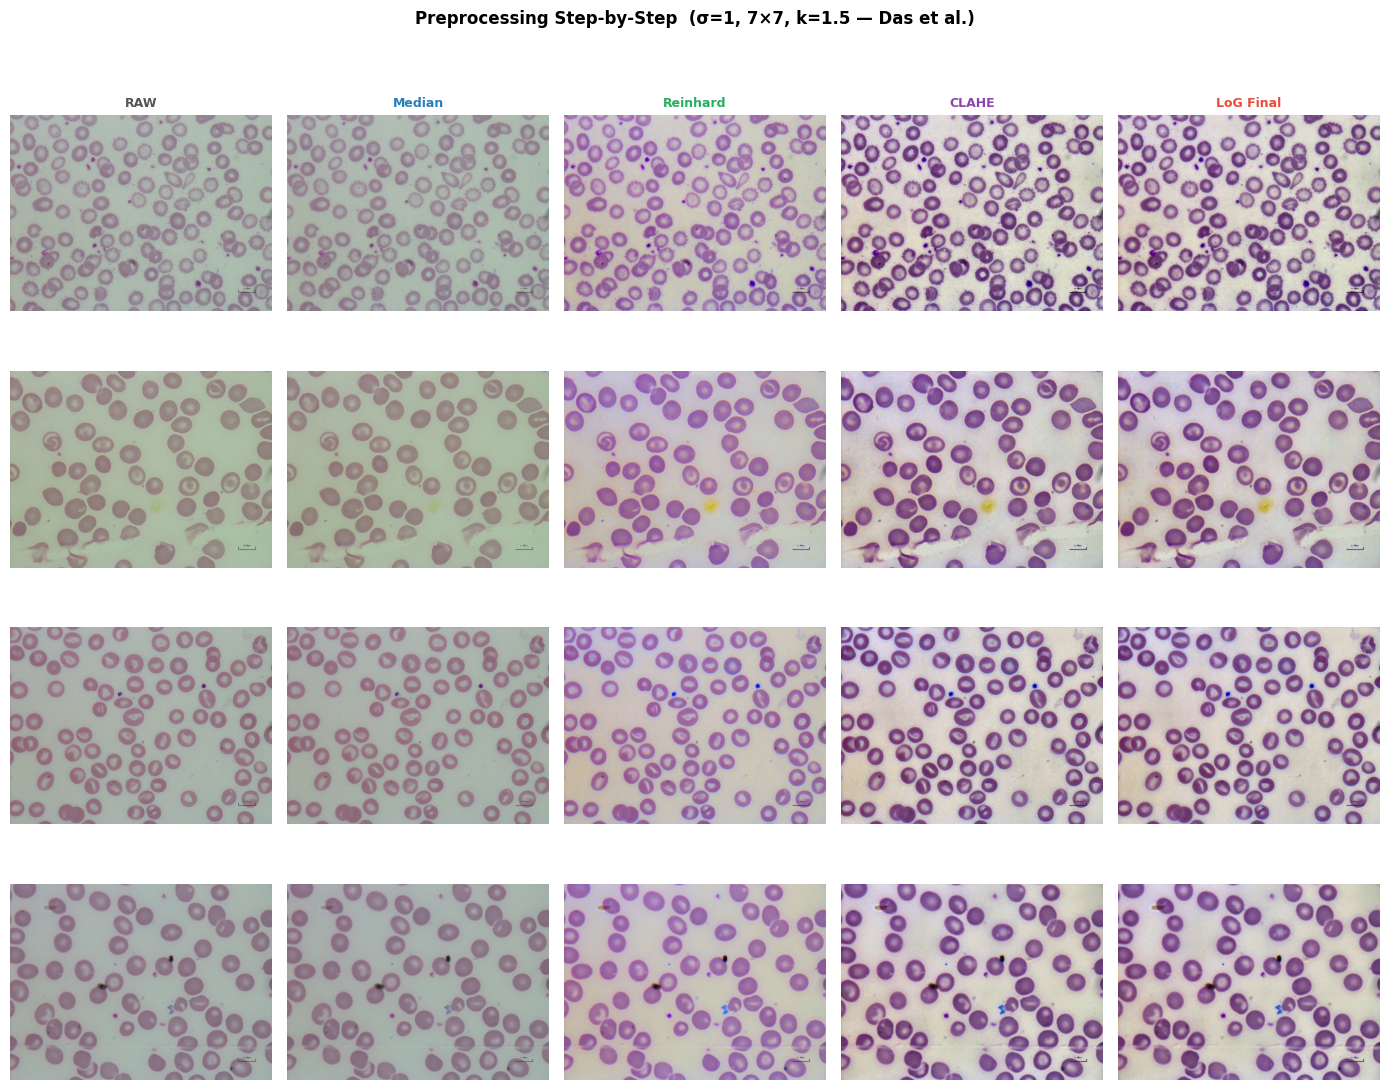

✔ Preprocessing OK — σ=1.5, kernel 5×5, k=0.5


In [3]:
# ── LoG parameters — sesuai Das et al. Eq. 1 & 2
LOG_SIGMA       = 1.5   
LOG_KERNEL_SIZE = 5     
LOG_K           = 0.5   


def _build_log_kernel(size=LOG_KERNEL_SIZE, sigma=LOG_SIGMA):
    """
    Kernel LoG analitik — Das et al. Eq. 2:
      LG(x,y) = -(1/πσ⁴) · (1 - (x²+y²)/2σ²) · exp(-(x²+y²)/2σ²)
    Kernel di-zero-sum agar tidak ada DC shift pada gambar.
    """
    k = size // 2
    y, x = np.mgrid[-k:k+1, -k:k+1].astype(np.float64)
    r2     = x**2 + y**2
    kernel = -(1.0 / (np.pi * sigma**4)) * \
             (1 - r2 / (2 * sigma**2)) * \
             np.exp(-r2 / (2 * sigma**2))
    kernel -= kernel.mean()   # zero-sum
    return kernel.astype(np.float32)


def _apply_log_sharpening(img_rgb, k=LOG_K):
    """
    Highboosting — Das et al. Eq. 1: FI = CI + k·LG(CI)
    Diterapkan per channel RGB (sesuai paper: color image input/output).
    """
    img_f  = img_rgb.astype(np.float32) / 255.0
    log_k  = _build_log_kernel()
    result = np.zeros_like(img_f)
    for i in range(3):
        log_resp        = cv2.filter2D(img_f[:, :, i], cv2.CV_32F, log_k)
        result[:, :, i] = img_f[:, :, i] + k * log_resp   # tanda + sesuai Eq.1
    return np.clip(result, 0.0, 1.0)


def preprocess_image(img_rgb, ref_img_path=None):
    """
    Pipeline 4 tahap:
      1. Median Filter (kernel=3)
      2. Reinhard Normalization (LAB, per-channel mean/std transfer)
      3. CLAHE (L-channel LAB, clipLimit=2.0, tileGrid=8×8)
      4. LoG Highboosting (sesuai Das et al. Eq.1 & 2)
    """
    img_rgb = np.clip(img_rgb, 0, 255).astype(np.uint8)

    # ── 1. Median Filter
    img_median = cv2.medianBlur(img_rgb, 3)

    # ── 2. Reinhard Normalization
    img_reinhard = img_median
    if ref_img_path and os.path.exists(ref_img_path):
        ref_bgr = cv2.imread(ref_img_path, cv2.IMREAD_COLOR)
        if ref_bgr is not None:
            ref_rgb = cv2.cvtColor(ref_bgr, cv2.COLOR_BGR2RGB)
            try:
                src = cv2.cvtColor(img_median, cv2.COLOR_RGB2LAB).astype(np.float32)
                tgt = cv2.cvtColor(ref_rgb,    cv2.COLOR_RGB2LAB).astype(np.float32)
                eps = 1e-6
                channels = []
                for i in range(3):
                    s, t   = src[:, :, i], tgt[:, :, i]
                    # Rumus Reinhard: out = (s - μ_s) * (σ_t/σ_s) + μ_t
                    mapped = (s - s.mean()) * (t.std() / (s.std() + eps)) + t.mean()
                    channels.append(np.clip(mapped, 0, 255).astype(np.float32))
                merged       = cv2.merge(channels).astype(np.uint8)
                img_reinhard = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
            except Exception:
                pass   # fallback ke img_median

    # ── 3. CLAHE pada L-channel LAB
    lab    = cv2.cvtColor(img_reinhard, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)
    clahe  = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    L_cl   = clahe.apply(L)
    img_clahe = cv2.cvtColor(cv2.merge([L_cl, A, B]), cv2.COLOR_LAB2RGB)

    # ── 4. LoG Highboosting (Das et al. Eq. 1 & 2)
    img_log_f = _apply_log_sharpening(img_clahe, k=LOG_K)
    img_final = (img_log_f * 255).astype(np.uint8)

    return {
        "RAW"      : img_rgb,
        "Median"   : img_median,
        "Reinhard" : img_reinhard,
        "CLAHE"    : img_clahe,
        "LoG Final": img_final,
        "_final"   : img_final,
    }


# ── Visualisasi preprocessing pada N_SAMPLE gambar
np.random.seed(RANDOM_SEED)
sample_pp   = np.random.choice(img_files, min(N_SAMPLE, len(img_files)), replace=False)
steps       = ["RAW", "Median", "Reinhard", "CLAHE", "LoG Final"]
step_colors = ["#555", "#2980B9", "#27AE60", "#8E44AD", "#E74C3C"]

fig, axes = plt.subplots(len(sample_pp), len(steps),
                         figsize=(len(steps) * 2.8, len(sample_pp) * 2.8))
fig.suptitle("Preprocessing Step-by-Step  (σ=1, 7×7, k=1.5 — Das et al.)",
             fontsize=12, fontweight="bold", y=1.01)

for row, path in enumerate(sample_pp):
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    res     = preprocess_image(img_rgb, ref_img_path=REF_IMG_PATH)
    for col, step in enumerate(steps):
        ax = axes[row, col] if len(sample_pp) > 1 else axes[col]
        ax.imshow(res[step])
        if row == 0:
            ax.set_title(step, fontsize=9, fontweight="bold", color=step_colors[col])
        if col == 0:
            ax.set_ylabel(os.path.basename(path)[:18], fontsize=7,
                          rotation=0, labelpad=60, va="center")
        ax.axis("off")

plt.tight_layout()
plt.show()
print(f"✔ Preprocessing OK — σ={LOG_SIGMA}, kernel {LOG_KERNEL_SIZE}×{LOG_KERNEL_SIZE}, k={LOG_K}")

## Cell 4 — Isolasi Sel Target per Crop
**Masalah:** crop 80×80 sering menangkap sel tetangga atau fragment WBC di tepi.

**Solusi:** Setelah crop, ambil *connected component* yang centroid-nya **paling dekat ke titik tengah crop** (= lokasi label). Komponen lain diabaikan. Ini jauh lebih ringan dari BO-FRS dan cukup untuk kasus crop 1-sel-dominan.

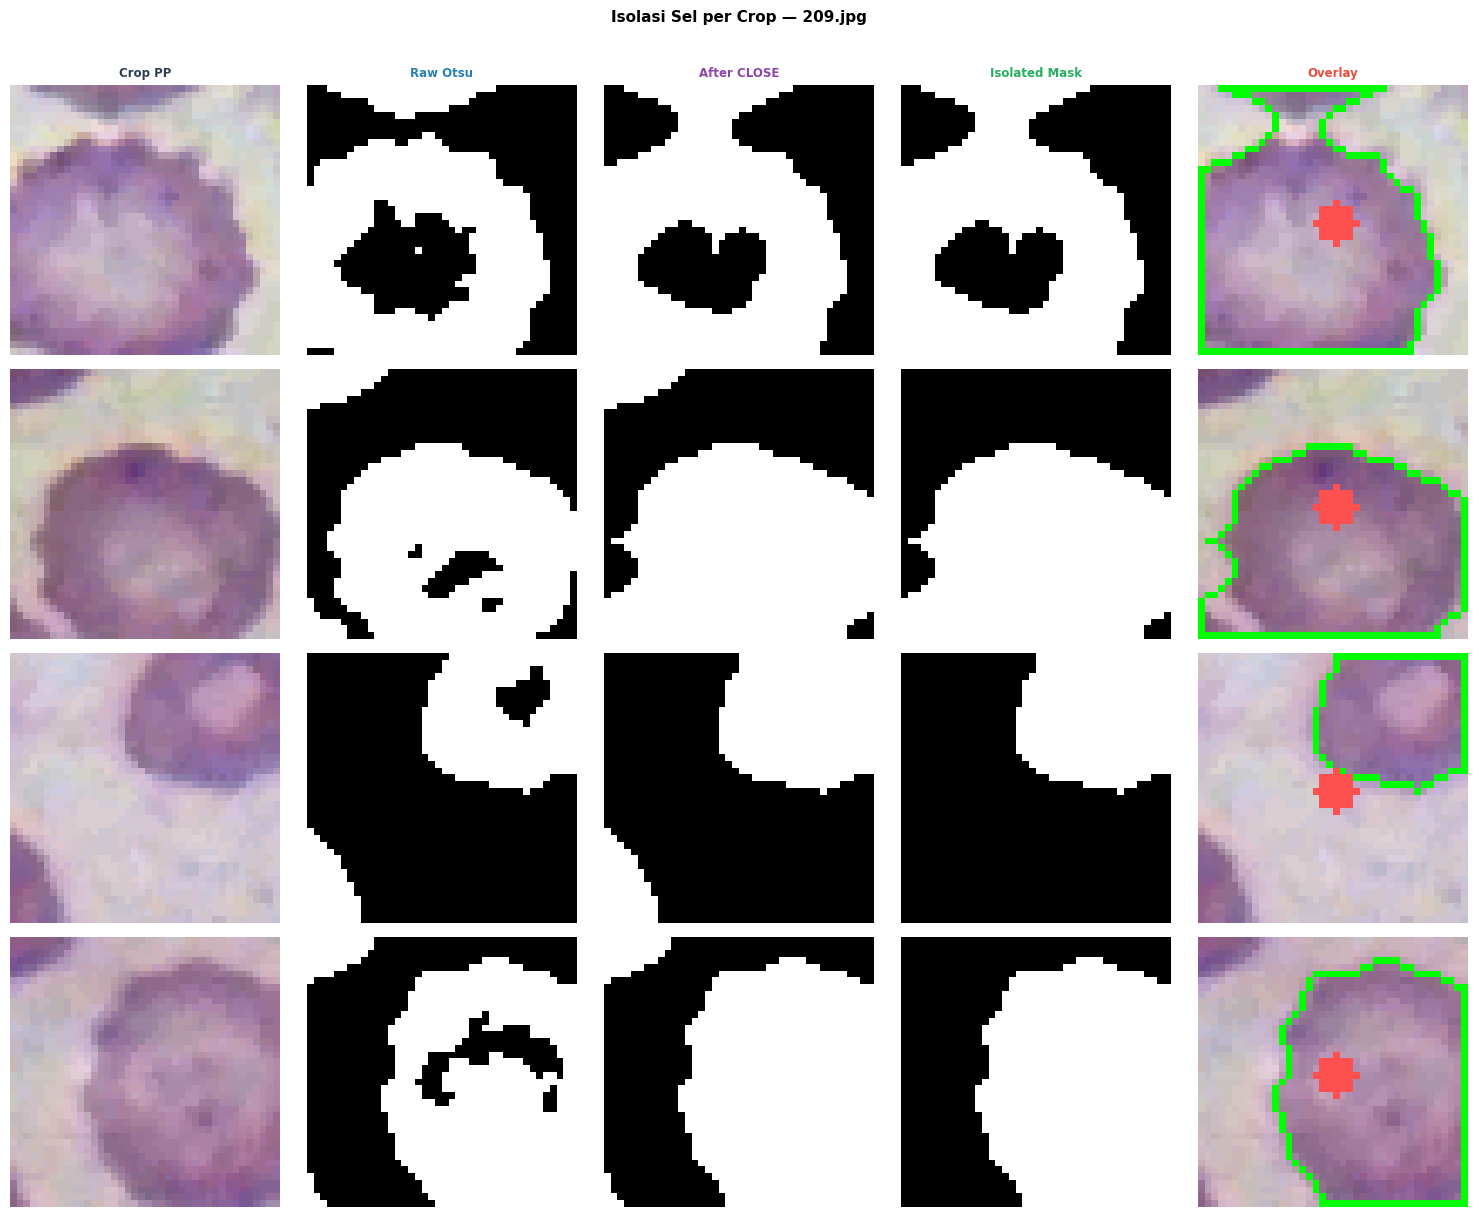

✔ 4 crop ditampilkan
  Titik merah = lokasi label (cx,cy) = seharusnya pusat sel
  Kontur hijau = batas sel terpilih (isolated mask)


In [4]:
def isolate_target_cell(crop_bgr):
    """
    Dari crop BGR 80×80, kembalikan binary mask (uint8, 0/255) yang
    hanya berisi sel RBC yang paling dekat ke titik tengah crop.

    Langkah:
      1. Konversi ke LAB → ambil L-channel
      2. Otsu INV pada L-channel → sel lebih gelap dari background
      3. MORPH_CLOSE 7×7 → tutup lubang pallor di tengah sel
      4. Label connected components
      5. Pilih komponen yang centroid-nya paling dekat ke (cx, cy) tengah crop
      6. Kembalikan mask hanya komponen terpilih

    Returns:
        cell_mask  : np.ndarray (H, W, uint8) — 255 = sel, 0 = background
        found      : bool — True jika ada komponen yang valid ditemukan
    """
    h, w  = crop_bgr.shape[:2]
    cy_c  = h / 2.0   # titik tengah crop (target lokasi sel)
    cx_c  = w / 2.0

    # ── 1. LAB L-channel
    lab   = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2LAB)
    L_ch  = lab[:, :, 0]

    # ── 2. Otsu INV: sel lebih gelap → foreground = 255
    _, raw_mask = cv2.threshold(
        L_ch, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # ── 3. MORPH_CLOSE: tutup lubang pallor
    k_close   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    closed    = cv2.morphologyEx(raw_mask, cv2.MORPH_CLOSE, k_close)

    # ── 4. Label connected components
    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        closed, connectivity=8
    )
    # label 0 = background, skip

    MIN_AREA = 200   # pixel — abaikan noise kecil

    best_label = -1
    best_dist  = float('inf')

    for lbl in range(1, n_labels):
        area = stats[lbl, cv2.CC_STAT_AREA]
        if area < MIN_AREA:
            continue
        ccx, ccy = centroids[lbl]   # centroid komponen ini
        dist = np.sqrt((ccx - cx_c)**2 + (ccy - cy_c)**2)
        if dist < best_dist:
            best_dist  = dist
            best_label = lbl

    if best_label == -1:
        # Tidak ada komponen valid — kembalikan mask kosong
        return np.zeros((h, w), dtype=np.uint8), False

    # ── 5. Buat mask hanya komponen terpilih
    cell_mask = np.where(labels == best_label, 255, 0).astype(np.uint8)
    return cell_mask, True


# ── Debug visual: tampilkan isolasi sel pada N_SAMPLE crop
np.random.seed(RANDOM_SEED)
paired = []
for txt_path in txt_files:
    base = os.path.splitext(os.path.basename(txt_path))[0]
    for ext in [".jpg", ".png", ".jpeg"]:
        img_p = os.path.join(IMG_DIR, base + ext)
        if os.path.exists(img_p):
            paired.append((img_p, txt_path))
            break

if not paired:
    print("⚠ Tidak ada pasangan gambar+TXT")
else:
    img_path, txt_path = paired[np.random.randint(len(paired))]
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    res     = preprocess_image(img_rgb, ref_img_path=REF_IMG_PATH)
    img_pp  = cv2.cvtColor(res["_final"], cv2.COLOR_RGB2BGR)
    h_img, w_img = img_pp.shape[:2]

    crops_all = []
    with open(txt_path) as f:
        for line in f:
            d = line.strip().split()
            if len(d) >= 3:
                xc, yc, lbl = int(d[0]), int(d[1]), int(d[2])
                x0 = max(0, xc-HALF); y0 = max(0, yc-HALF)
                x1 = min(w_img, xc+HALF); y1 = min(h_img, yc+HALF)
                crop = img_pp[y0:y1, x0:x1]
                if crop.size > 0:
                    crops_all.append((crop, lbl, xc, yc))

    sample_crops = [crops_all[i] for i in
                    np.random.choice(len(crops_all), min(N_SAMPLE, len(crops_all)), replace=False)]

    col_titles = ["Crop PP", "Raw Otsu", "After CLOSE", "Isolated Mask", "Overlay"]
    col_colors = ["#2C3E50", "#2980B9", "#8E44AD", "#27AE60", "#E74C3C"]

    fig, axes = plt.subplots(len(sample_crops), 5,
                             figsize=(15, len(sample_crops) * 3))
    fig.suptitle(f"Isolasi Sel per Crop — {os.path.basename(img_path)}",
                 fontsize=11, fontweight="bold", y=1.01)

    for row, (crop_bgr, lbl, xc, yc) in enumerate(sample_crops):
        h_c, w_c = crop_bgr.shape[:2]
        crop_rgb  = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)

        # Raw Otsu (sebelum CLOSE)
        lab_c = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2LAB)
        L_c   = lab_c[:, :, 0]
        _, raw_otsu = cv2.threshold(L_c, 0, 255,
                                    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        # After CLOSE
        k_cl   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        closed = cv2.morphologyEx(raw_otsu, cv2.MORPH_CLOSE, k_cl)

        # Isolated mask
        iso_mask, found = isolate_target_cell(crop_bgr)

        # Overlay: kontur hijau di atas crop asli
        overlay = crop_rgb.copy()
        if found:
            contours, _ = cv2.findContours(iso_mask, cv2.RETR_EXTERNAL,
                                           cv2.CHAIN_APPROX_SIMPLE)
            overlay_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
            cv2.drawContours(overlay_bgr, contours, -1, (0, 255, 0), 1)
            overlay = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)
        # Tandai titik tengah crop (lokasi label)
        cv2.circle(overlay, (w_c//2, h_c//2), 3, (255, 80, 80), -1)

        panels = [crop_rgb, raw_otsu, closed, iso_mask, overlay]
        cmaps  = [None, "gray", "gray", "gray", None]

        for col, (panel, cmap) in enumerate(zip(panels, cmaps)):
            ax = axes[row, col] if len(sample_crops) > 1 else axes[col]
            ax.imshow(panel, cmap=cmap)
            if row == 0:
                ax.set_title(col_titles[col], fontsize=8.5,
                             fontweight="bold", color=col_colors[col])
            if col == 0:
                nama = NAMA_LABEL.get(lbl, f"L{lbl}")
                ax.set_ylabel(f"{nama}\n({xc},{yc})", fontsize=7,
                              rotation=0, labelpad=55, va="center")
            ax.axis("off")

    plt.tight_layout()
    plt.show()
    print(f"✔ {len(sample_crops)} crop ditampilkan")
    print("  Titik merah = lokasi label (cx,cy) = seharusnya pusat sel")
    print("  Kontur hijau = batas sel terpilih (isolated mask)")

## Cell 5 — Ekstraksi Fitur (Fixed)
**Perbaikan:**
- Cell mask: LAB L-channel Otsu INV + MORPH_CLOSE 7×7 (bukan Green channel)
- CP mask: percentile-75 pada L-channel pixel dalam sel (bukan mean+1.2σ)
- **Input mask**: pakai `isolate_target_cell()` bukan Otsu ulang — jadi sel tetangga sudah terisolasi

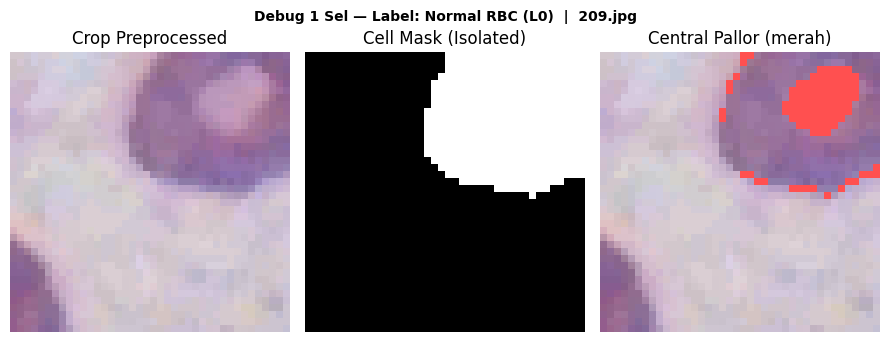


  Total fitur : 38
  Label       : L0 — Normal RBC
  CP_Ratio    : 0.1684  (>0.3 → normal pallor)
  Area        : 380.0 px²


,Nilai
Fitur,
Cell_Label,0.0000
Area,380.0000
Perimeter,76.9700
Major_Axis,26.8800
Minor_Axis,22.2400
Compactness,1.2407
Eccentricity,0.5614
Solidity,0.9719
Aspect_Ratio,1.2084


In [5]:
def ekstrak_fitur_satu_sel(crop_bgr, label):
    """
    Ekstrak 40 fitur dari satu crop sel RBC (BGR, uint8).

    Pipeline internal:
      1. isolate_target_cell → cell_mask (hanya sel terdekat ke tengah crop)
      2. Fitur morfologi dari kontur cell_mask
      3. Fitur warna dari pixel BGR asli di dalam cell_mask
      4. CP mask via percentile-75 L-channel → fitur pallor
      5. GLCM dari grayscale asli

    Returns:
        dict fitur, cp_mask, cell_mask
    """
    h, w = crop_bgr.shape[:2]

    # ── 0. Konversi ruang warna
    lab   = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2LAB)
    L_ch  = lab[:, :, 0]
    b_ch, g_ch, r_ch = cv2.split(crop_bgr)

    # ── 1. Cell mask via isolasi komponen terdekat ke tengah
    cell_mask, found = isolate_target_cell(crop_bgr)

    # ── 2. Fitur morfologi
    area = perimeter = maj_ax = min_ax = 0
    compactness = eccentricity = solidity = aspect_ratio = 0
    rectangularity = convexity = circularity_ratio = euler_number = 0

    contours, _ = cv2.findContours(
        cell_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    if contours:
        c         = max(contours, key=cv2.contourArea)
        area      = cv2.contourArea(c)
        perimeter = cv2.arcLength(c, True)
        _, _, wc, hc = cv2.boundingRect(c)
        rectangularity = area / (wc * hc) if wc * hc > 0 else 0
        if len(c) >= 5:
            (_, _), (min_ax, maj_ax), _ = cv2.fitEllipse(c)
            aspect_ratio = maj_ax / min_ax if min_ax > 0 else 0
            eccentricity = (
                np.sqrt(1 - (min_ax**2 / maj_ax**2))
                if maj_ax > min_ax else 0
            )
        hull       = cv2.convexHull(c)
        hull_area  = cv2.contourArea(hull)
        hull_perim = cv2.arcLength(hull, True)
        solidity   = area / hull_area if hull_area > 0 else 0
        convexity  = hull_perim / perimeter if perimeter > 0 else 0
        compactness       = (perimeter**2) / (4 * np.pi * area) if area > 0 else 0
        circularity_ratio = area / (perimeter**2) if perimeter > 0 else 0

    # ── 3. Fitur warna (dari pixel asli di dalam cell_mask)
    mask_px = cell_mask == 255
    r_pix   = r_ch[mask_px]
    g_pix   = g_ch[mask_px]
    b_pix   = b_ch[mask_px]
    if len(r_pix) == 0:
        r_pix = g_pix = b_pix = np.array([0], dtype=np.uint8)

    c_mean_r, c_std_r  = float(np.mean(r_pix)), float(np.std(r_pix))
    c_skew_r, c_kurt_r = float(skew(r_pix)),    float(kurtosis(r_pix))
    c_mean_g, c_std_g  = float(np.mean(g_pix)), float(np.std(g_pix))
    c_skew_g, c_kurt_g = float(skew(g_pix)),    float(kurtosis(g_pix))
    c_mean_b, c_std_b  = float(np.mean(b_pix)), float(np.std(b_pix))
    c_skew_b, c_kurt_b = float(skew(b_pix)),    float(kurtosis(b_pix))

    # ── 4. CP mask — percentile-75 L-channel di dalam sel
    #       25% pixel paling terang di dalam sel = zona central pallor
    cp_mask = np.zeros((h, w), dtype=np.uint8)
    l_pix_in = L_ch[mask_px]
    if len(l_pix_in) > 0:
        thresh_cp = float(np.percentile(l_pix_in, 75))
        _, cp_raw = cv2.threshold(L_ch, thresh_cp, 255, cv2.THRESH_BINARY)
        cp_mask   = cv2.bitwise_and(cp_raw, cp_raw, mask=cell_mask)

    # ── 5. Euler number dari CP mask
    cp_contours, _ = cv2.findContours(
        cp_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    euler_number = 1 - sum(
        1 for cc in cp_contours if cv2.contourArea(cc) > 10
    )

    # ── 6. Fitur central pallor
    cp_area = cp_perim = cp_maj = cp_min = 0
    cp_comp = cp_ecc = cp_solid = cp_ratio = 0

    if cp_contours:
        c_cp     = max(cp_contours, key=cv2.contourArea)
        cp_area  = cv2.contourArea(c_cp)
        cp_perim = cv2.arcLength(c_cp, True)
        cp_ratio = cp_area / area if area > 0 else 0
        if len(c_cp) >= 5:
            _, (cp_min, cp_maj), _ = cv2.fitEllipse(c_cp)
            cp_ecc = (
                np.sqrt(1 - (cp_min**2 / cp_maj**2))
                if cp_maj > cp_min else 0
            )
        hull_cp      = cv2.convexHull(c_cp)
        hull_cp_area = cv2.contourArea(hull_cp)
        cp_solid = cp_area / hull_cp_area if hull_cp_area > 0 else 0
        cp_comp  = (cp_perim**2) / (4 * np.pi * cp_area) if cp_area > 0 else 0

    # ── 7. Pallor contrast & ratio (R-channel)
    pallor_px       = cp_mask == 255
    rim_px          = mask_px & (cp_mask == 0)
    r_pallor        = float(r_ch[pallor_px].mean()) if pallor_px.any() else 0.0
    r_rim           = float(r_ch[rim_px].mean())    if rim_px.any()    else 0.0
    pallor_contrast = r_pallor - r_rim
    pallor_ratio_r  = r_pallor / r_rim if r_rim > 0 else 0.0

    # ── 8. GLCM tekstur (dari grayscale asli)
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(
        gray, distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=256, symmetric=True, normed=True
    )
    contrast_g    = graycoprops(glcm, 'contrast')[0]
    correlation_g = graycoprops(glcm, 'correlation')[0]
    energy_g      = graycoprops(glcm, 'energy')[0]
    homogeneity_g = graycoprops(glcm, 'homogeneity')[0]

    return {
        "Cell_Label"            : label,
        "Area"                  : round(area, 2),
        "Perimeter"             : round(perimeter, 2),
        "Major_Axis"            : round(maj_ax, 2),
        "Minor_Axis"            : round(min_ax, 2),
        "Compactness"           : round(compactness, 4),
        "Eccentricity"          : round(eccentricity, 4),
        "Solidity"              : round(solidity, 4),
        "Aspect_Ratio"          : round(aspect_ratio, 4),
        "Rectangularity"        : round(rectangularity, 4),
        "Convexity"             : round(convexity, 4),
        "Circularity_Ratio"     : round(circularity_ratio, 4),
        "Euler_Number"          : euler_number,
        "CP_Area"               : round(cp_area, 2),
        "CP_Perimeter"          : round(cp_perim, 2),
        "CP_Major_Axis"         : round(cp_maj, 2),
        "CP_Minor_Axis"         : round(cp_min, 2),
        "CP_Compactness"        : round(cp_comp, 4),
        "CP_Eccentricity"       : round(cp_ecc, 4),
        "CP_Solidity"           : round(cp_solid, 4),
        "CP_Ratio"              : round(cp_ratio, 4),
        "Pallor_Contrast_R"     : round(pallor_contrast, 4),
        "Pallor_Ratio_R"        : round(pallor_ratio_r, 4),
        "GLCM_Contrast_Mean"    : round(float(np.mean(contrast_g)), 6),
        "GLCM_Correlation_Mean" : round(float(np.mean(correlation_g)), 6),
        "GLCM_Energy_Mean"      : round(float(np.mean(energy_g)), 6),
        "GLCM_Homogeneity_Mean" : round(float(np.mean(homogeneity_g)), 6),
        "Color_Mean_R"          : round(c_mean_r, 4),
        "Color_Std_R"           : round(c_std_r, 4),
        "Color_Skewness_R"      : round(c_skew_r, 4),
        "Color_Kurtosis_R"      : round(c_kurt_r, 4),
        "Color_Mean_G"          : round(c_mean_g, 4),
        "Color_Std_G"           : round(c_std_g, 4),
        "Color_Skewness_G"      : round(c_skew_g, 4),
        "Color_Kurtosis_G"      : round(c_kurt_g, 4),
        "Color_Mean_B"          : round(c_mean_b, 4),
        "Color_Std_B"           : round(c_std_b, 4),
        "Color_Skewness_B"      : round(c_skew_b, 4),
        "Color_Kurtosis_B"      : round(c_kurt_b, 4),
    }, cp_mask, cell_mask


# ── Debug 1 sel
np.random.seed(RANDOM_SEED)
img_path, txt_path = paired[np.random.randint(len(paired))]
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
res     = preprocess_image(img_rgb, ref_img_path=REF_IMG_PATH)
img_pp  = cv2.cvtColor(res["_final"], cv2.COLOR_RGB2BGR)
h_img, w_img = img_pp.shape[:2]

with open(txt_path) as f:
    for line in f:
        d = line.strip().split()
        if len(d) >= 3:
            xc, yc, lbl = int(d[0]), int(d[1]), int(d[2])
            break

x0 = max(0, xc-HALF); y0 = max(0, yc-HALF)
x1 = min(w_img, xc+HALF); y1 = min(h_img, yc+HALF)
cell_bgr = img_pp[y0:y1, x0:x1]

fitur, cp_mask, cell_mask = ekstrak_fitur_satu_sel(cell_bgr, label=lbl)

fig, axes = plt.subplots(1, 3, figsize=(9, 3.5))
fig.suptitle(
    f"Debug 1 Sel — Label: {NAMA_LABEL.get(lbl,'?')} (L{lbl})  |  {os.path.basename(img_path)}",
    fontsize=10, fontweight="bold"
)
axes[0].imshow(cv2.cvtColor(cell_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Crop Preprocessed"); axes[0].axis("off")
axes[1].imshow(cell_mask, cmap="gray")
axes[1].set_title("Cell Mask (Isolated)"); axes[1].axis("off")
cp_vis = cv2.cvtColor(cell_bgr, cv2.COLOR_BGR2RGB).copy()
cp_vis[cp_mask == 255] = [255, 80, 80]
axes[2].imshow(cp_vis)
axes[2].set_title("Central Pallor (merah)"); axes[2].axis("off")
plt.tight_layout()
plt.show()

df_fitur = pd.DataFrame([fitur]).T
df_fitur.columns = ["Nilai"]
df_fitur.index.name = "Fitur"
print(f"\n{'='*45}")
print(f"  Total fitur : {len(fitur)-1}")
print(f"  Label       : L{lbl} — {NAMA_LABEL.get(lbl,'?')}")
print(f"  CP_Ratio    : {fitur['CP_Ratio']:.4f}  (>0.3 → normal pallor)")
print(f"  Area        : {fitur['Area']:.1f} px²")
print(f"{'='*45}")
display(df_fitur.style.format("{:.4f}").set_table_styles(
    [{"selector":"th","props":[("font-weight","bold"),("background-color","#E8F4FD")]}]
))

## Cell 6 — Batch Ekstraksi → CSV

In [6]:
list_fitur      = []
error_log       = []
skip_no_cell    = 0
gambar_diproses = 0
t_start         = time.time()

DIR_CROP = os.path.join(OUTPUT_DIR, "Dataset_Cropped")
os.makedirs(DIR_CROP, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Total file TXT : {len(txt_files)}")
print(f"Output         : {OUTPUT_DIR}")
print(f"{'─'*55}")

for i, txt_path in enumerate(txt_files):
    base_name = os.path.splitext(os.path.basename(txt_path))[0]
    img_path  = None
    for ext in [".jpg", ".png", ".jpeg"]:
        p = os.path.join(IMG_DIR, base_name + ext)
        if os.path.exists(p):
            img_path = p
            break
    if img_path is None:
        error_log.append(f"Gambar tidak ditemukan: {base_name}")
        continue

    try:
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            error_log.append(f"Gagal baca: {img_path}")
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        res     = preprocess_image(img_rgb, ref_img_path=REF_IMG_PATH)
        img_pp  = cv2.cvtColor(res["_final"], cv2.COLOR_RGB2BGR)
        h_img, w_img = img_pp.shape[:2]
        gambar_diproses += 1

        with open(txt_path) as f:
            lines = f.readlines()

        for line in lines:
            data = line.strip().split()
            if len(data) < 3:
                continue
            xc, yc, label = int(data[0]), int(data[1]), int(data[2])

            x0 = max(0, xc-HALF); y0 = max(0, yc-HALF)
            x1 = min(w_img, xc+HALF); y1 = min(h_img, yc+HALF)
            crop_bgr = img_pp[y0:y1, x0:x1]
            if crop_bgr.size == 0:
                continue

            # Cek dulu apakah sel valid ditemukan
            _, found = isolate_target_cell(crop_bgr)
            if not found:
                skip_no_cell += 1
                continue

            # Simpan crop
            class_dir = os.path.join(DIR_CROP, f"class_{label}")
            os.makedirs(class_dir, exist_ok=True)
            cv2.imwrite(
                os.path.join(class_dir, f"{base_name}_{xc}_{yc}.jpg"),
                crop_bgr
            )

            # Ekstraksi fitur
            fitur, _, _ = ekstrak_fitur_satu_sel(crop_bgr, label=label)
            fitur["Source_Image"] = base_name
            fitur["X"] = xc
            fitur["Y"] = yc
            list_fitur.append(fitur)

    except Exception as e:
        error_log.append(f"{base_name}: {str(e)}")
        continue

    elapsed = time.time() - t_start
    rate    = gambar_diproses / elapsed if elapsed > 0 else 0
    eta     = (len(txt_files) - i - 1) / rate if rate > 0 else 0
    pct     = (i + 1) / len(txt_files) * 100
    bar     = "█" * int(pct / 5) + "░" * (20 - int(pct / 5))
    print(f"  [{bar}] {pct:5.1f}%  {i+1:>4}/{len(txt_files)} gambar"
          f"  | {len(list_fitur):,} sel  | skip: {skip_no_cell}  | ETA: {eta:.0f}s",
          end="\r")

print()
csv_path = os.path.join(OUTPUT_DIR, "dataset_fitur_TA_Lengkap.csv")
df = pd.DataFrame(list_fitur)

meta_cols = ["Cell_Label", "Source_Image", "X", "Y"]
feat_cols = [c for c in df.columns if c not in meta_cols]
df = df[meta_cols + feat_cols]
df.to_csv(csv_path, index=False)

print(f"\n{'='*55}")
print(f"  ✔ Selesai!")
print(f"  Gambar diproses  : {gambar_diproses}")
print(f"  Total sel        : {len(list_fitur):,}")
print(f"  Dilewati (no cell): {skip_no_cell}")
print(f"  Error            : {len(error_log)}")
print(f"  CSV              : {csv_path}")
print(f"  Shape            : {df.shape}")
print(f"  Waktu total      : {time.time()-t_start:.1f}s")
print(f"{'='*55}")
if error_log:
    print(f"\n⚠ Error (5 pertama):")
    for e in error_log[:5]:
        print(f"  {e}")

Total file TXT : 623
Output         : C:\Users\Yohanes\OneDrive\Documents\COLLEGE\8th Semester\Tugas Akhir\Result\3_Ekstraksi Fitur
───────────────────────────────────────────────────────
  [████████████████████] 100.0%   623/623 gambar  | 22,098 sel  | skip: 8  | ETA: 0ssss

  ✔ Selesai!
  Gambar diproses  : 623
  Total sel        : 22,098
  Dilewati (no cell): 8
  Error            : 0
  CSV              : C:\Users\Yohanes\OneDrive\Documents\COLLEGE\8th Semester\Tugas Akhir\Result\3_Ekstraksi Fitur\dataset_fitur_TA_Lengkap.csv
  Shape            : (22098, 42)
  Waktu total      : 1451.7s


## Cell 7 — Validasi CSV & Distribusi Fitur

Shape   : (22098, 42)
NaN     : 0

Distribusi label:
  L 0 (Normal RBC     ): 6,327 ( 28.6%)
  L 1 (Macrocyte      ):   688 (  3.1%)
  L 2 (Microcyte      ):   461 (  2.1%) ← IDA
  L 3 (Spherocyte     ): 3,449 ( 15.6%)
  L 4 (Target Cell    ): 2,753 ( 12.5%)
  L 5 (Stomatocyte    ): 1,995 (  9.0%) ← IDA
  L 6 (Ovalocyte      ): 2,140 (  9.7%) ← IDA
  L 7 (Teardrop       ):   307 (  1.4%)
  L 8 (Burr Cell      ):   784 (  3.5%)
  L 9 (Schistocyte    ):   895 (  4.1%)
  L10 (Other          ):   184 (  0.8%) ← IDA
  L11 (Hypochromic    ): 1,063 (  4.8%) ← IDA
  L12 (Elliptocyte    ): 1,052 (  4.8%) ← IDA


,Cell_Label,Source_Image,X,Y,Area,Perimeter,Major_Axis,Minor_Axis,Compactness,Eccentricity,...,Color_Skewness_R,Color_Kurtosis_R,Color_Mean_G,Color_Std_G,Color_Skewness_G,Color_Kurtosis_G,Color_Mean_B,Color_Std_B,Color_Skewness_B,Color_Kurtosis_B
0,0,1,594,95,1099.0,128.43,42.90,35.54,1.1943,0.5599,...,1.0509,2.2628,115.3661,15.3047,1.9142,4.7140,147.9214,15.5483,0.8032,1.5192
1,0,1,601,151,1077.5,127.36,43.10,38.99,1.1979,0.4260,...,1.7857,4.7648,103.6790,20.2580,2.0164,5.0911,140.3131,13.4187,0.9543,2.1051
2,0,1,556,153,1041.5,126.18,46.24,33.18,1.2166,0.6965,...,0.7354,1.1835,120.6701,15.5038,1.2092,1.8500,152.5415,13.0552,0.3391,0.3781


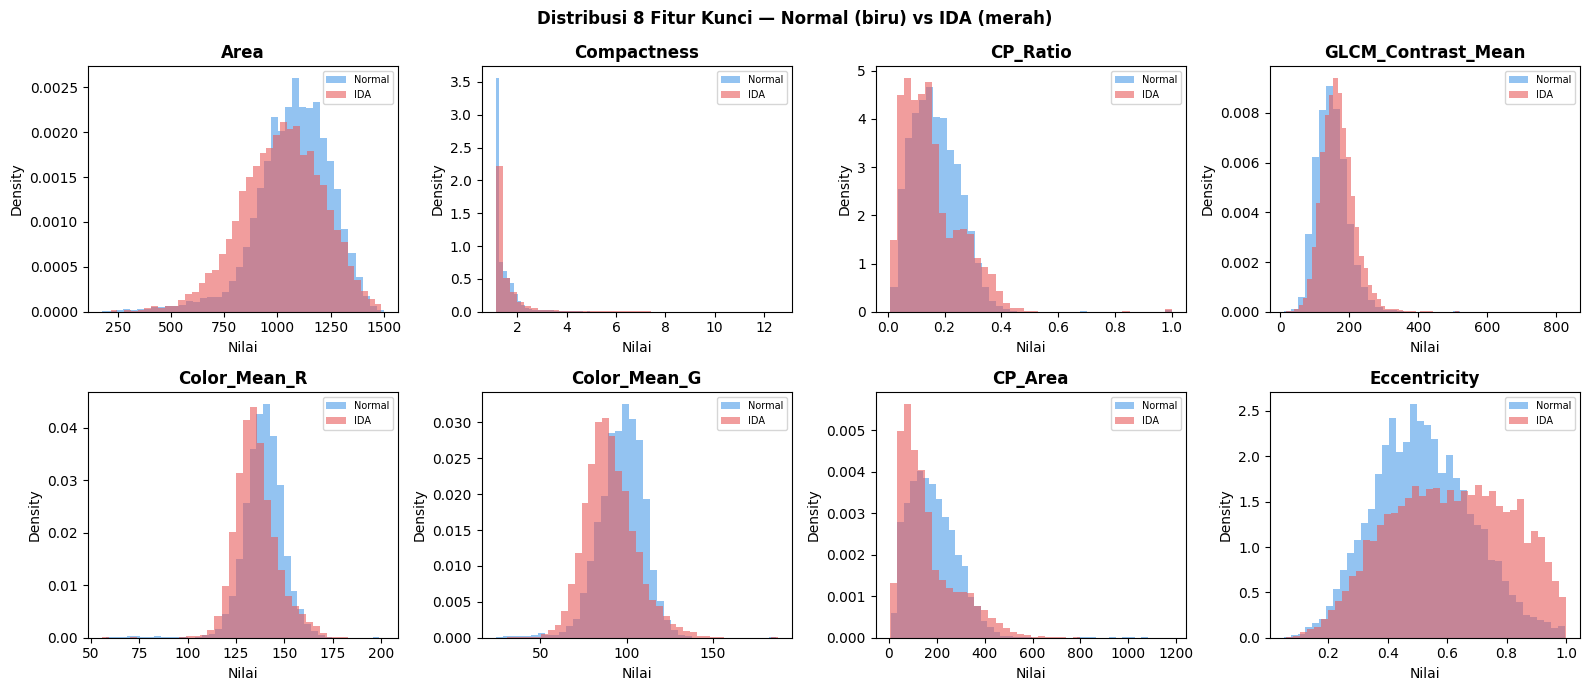


✔ Validasi selesai — CSV siap untuk training SVM


In [10]:
df_csv = pd.read_csv(csv_path)
print(f"Shape   : {df_csv.shape}")
print(f"NaN     : {df_csv.isna().sum().sum()}")
print(f"\nDistribusi label:")
for lbl, cnt in df_csv["Cell_Label"].value_counts().sort_index().items():
    pct  = cnt / len(df_csv) * 100
    nama = NAMA_LABEL.get(lbl, "?")
    tag  = " ← IDA" if lbl in IDA_LABELS else ""
    print(f"  L{lbl:2d} ({nama:15s}): {cnt:5,} ({pct:5.1f}%){tag}")

display(df_csv.head(3))

# ── Plot distribusi 8 fitur kunci: Normal vs IDA
key_feats = ["Area", "Compactness", "CP_Ratio", "GLCM_Contrast_Mean",
             "Color_Mean_R", "Color_Mean_G", "CP_Area", "Eccentricity"]

# Binary label: 0=Normal, 1=IDA
df_csv["IDA_binary"] = df_csv["Cell_Label"].apply(
    lambda x: 1 if x in IDA_LABELS else (0 if x == 0 else -1)
)
df_plot = df_csv[df_csv["IDA_binary"] >= 0]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Distribusi 8 Fitur Kunci — Normal (biru) vs IDA (merah)",
             fontsize=12, fontweight="bold")

for ax, feat in zip(axes.flat, key_feats):
    if feat not in df_plot.columns:
        ax.axis("off")
        continue
    normal_vals = df_plot[df_plot["IDA_binary"] == 0][feat].dropna()
    ida_vals    = df_plot[df_plot["IDA_binary"] == 1][feat].dropna()
    ax.hist(normal_vals, bins=40, alpha=0.6, color="#4C9BE8", label="Normal", density=True)
    ax.hist(ida_vals,    bins=40, alpha=0.6, color="#E85C5C", label="IDA",    density=True)
    ax.set_title(feat, fontweight="bold")
    ax.set_xlabel("Nilai")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()
print("\n✔ Validasi selesai — CSV siap untuk training SVM")

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL TAMBAHAN — Merge label IDA + Balancing (Binary: Normal=0 vs IDA=1)
# ═══════════════════════════════════════════════════════════════════════════════

import random
random.seed(RANDOM_SEED)

# ── 1. Label IDA yang digabung ────────────────────────────────────────────────
IDA_LABELS   = [2, 5, 6, 10, 11, 12]   # Microcyte, Stomatocyte, Ovalocyte,
                                         # Other, Hypochromic, Elliptocyte

df_raw       = pd.read_csv(csv_path)    # pakai csv_path dari cell sebelumnya

df_normal    = df_raw[df_raw["Cell_Label"] == 0].copy()
df_ida_all   = df_raw[df_raw["Cell_Label"].isin(IDA_LABELS)].copy()

TARGET_N     = len(df_normal)           # target = jumlah Normal (balanced)
MIN_PER_CLASS = 30

print("=" * 55)
print("BALANCING  —  Normal  vs  IDA  (Binary)")
print("=" * 55)
print(f"\nNormal  (label 0) : {len(df_normal):,}")
print(f"IDA gabungan      : {len(df_ida_all):,}  (labels {IDA_LABELS})")
print(f"TARGET per kelas  : {TARGET_N:,}\n")

# ── 2. Rincian IDA per sub-label sebelum sampling ─────────────────────────────
print("Sub-label IDA:")
sub_counts = {}
for lbl in sorted(df_ida_all["Cell_Label"].unique()):
    cnt = (df_ida_all["Cell_Label"] == lbl).sum()
    sub_counts[lbl] = cnt
    print(f"  L{lbl:2d} ({NAMA_LABEL.get(lbl,'?'):12s}): {cnt:,}")

# ── 3. Cap-based sampling (binary search) ─────────────────────────────────────
counts = sub_counts
lo, hi = 1, max(counts.values())
while lo < hi:
    mid = (lo + hi) // 2
    if sum(min(c, mid) for c in counts.values()) >= TARGET_N:
        hi = mid
    else:
        lo = mid + 1
cap = lo

quotas = {lbl: min(c, cap) for lbl, c in counts.items()}

# Trim overflow (round-robin dari kelas terbesar)
sorted_large = sorted(quotas, key=quotas.get, reverse=True)
idx = 0
while sum(quotas.values()) > TARGET_N:
    quotas[sorted_large[idx]] -= 1
    idx = (idx + 1) % len(sorted_large)

print(f"\nCap per sub-label IDA : {cap}")
print(f"\n{'Label':<8} {'Nama':<14} {'Asli':>7} {'Sampel':>8}")
print("-" * 42)
for lbl in sorted(quotas):
    print(f"  L{lbl:<6} {NAMA_LABEL.get(lbl,'?'):<14} {counts[lbl]:>7,} → {quotas[lbl]:>6,}")
print(f"  {'TOTAL':<20} {sum(counts.values()):>7,} → {sum(quotas.values()):>6,}")

# ── 4. Sample tiap sub-label IDA, gabung, remap label ─────────────────────────
parts = []
for lbl, n in quotas.items():
    if n < MIN_PER_CLASS:
        print(f"  [WARN] L{lbl} quota {n} < {MIN_PER_CLASS}, skip")
        continue
    parts.append(df_ida_all[df_ida_all["Cell_Label"] == lbl]
                            .sample(n=n, random_state=RANDOM_SEED))

df_ida_sampled              = pd.concat(parts, ignore_index=True)
df_normal_out               = df_normal.copy()

df_normal_out["Cell_Label"] = 0   # Normal → 0
df_ida_sampled["Cell_Label"] = 1  # IDA    → 1

df_binary = pd.concat([df_normal_out, df_ida_sampled], ignore_index=True)
df_binary  = df_binary.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# ── 5. Simpan ──────────────────────────────────────────────────────────────────
binary_csv = os.path.join(OUTPUT_DIR, "dataset_binary_Normal_IDA.csv")
df_binary.to_csv(binary_csv, index=False)

# ── 6. Ringkasan ───────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print(f"Shape final  : {df_binary.shape}")
print("Label distribution:")
for lbl, name in {0: "Normal", 1: "IDA"}.items():
    cnt = (df_binary["Cell_Label"] == lbl).sum()
    pct = cnt / len(df_binary) * 100
    print(f"  {name} ({lbl}): {cnt:,}  ({pct:.1f}%)")
print(f"\n✔ Disimpan → {binary_csv}")

BALANCING  —  Normal  vs  IDA  (Binary)

Normal  (label 0) : 6,327
IDA gabungan      : 6,895  (labels [2, 5, 6, 10, 11, 12])
TARGET per kelas  : 6,327

Sub-label IDA:
  L 2 (Microcyte   ): 461
  L 5 (Stomatocyte ): 1,995
  L 6 (Ovalocyte   ): 2,140
  L10 (Other       ): 184
  L11 (Hypochromic ): 1,063
  L12 (Elliptocyte ): 1,052

Cap per sub-label IDA : 1784

Label    Nama              Asli   Sampel
------------------------------------------
  L2      Microcyte          461 →    461
  L5      Stomatocyte      1,995 →  1,783
  L6      Ovalocyte        2,140 →  1,784
  L10     Other              184 →    184
  L11     Hypochromic      1,063 →  1,063
  L12     Elliptocyte      1,052 →  1,052
  TOTAL                  6,895 →  6,327

Shape final  : (12654, 42)
Label distribution:
  Normal (0): 6,327  (50.0%)
  IDA (1): 6,327  (50.0%)

✔ Disimpan → C:\Users\Yohanes\OneDrive\Documents\COLLEGE\8th Semester\Tugas Akhir\Result\3_Ekstraksi Fitur\dataset_binary_Normal_IDA.csv


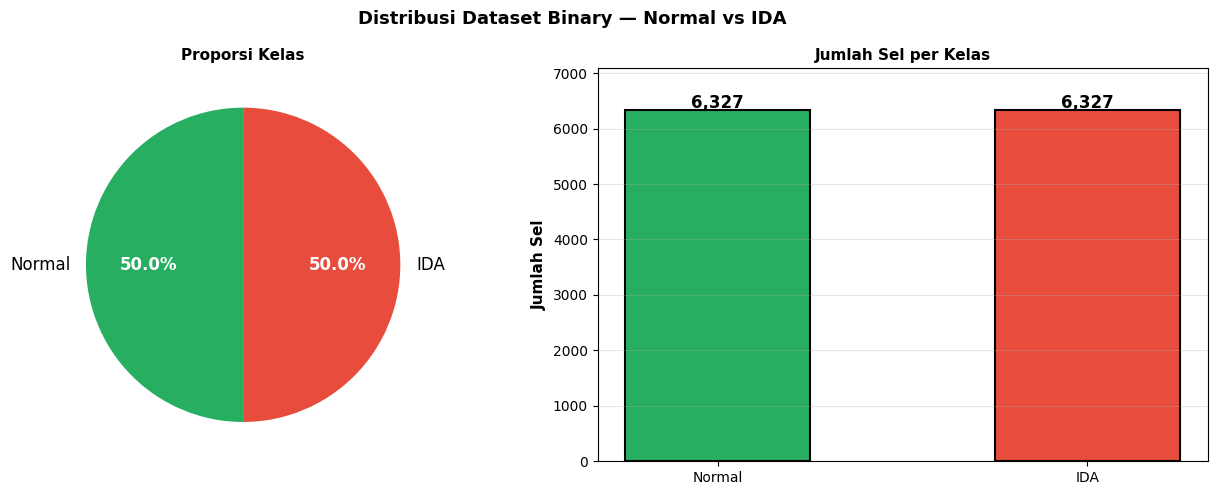

✔ Gambar disimpan → C:\Users\Yohanes\OneDrive\Documents\COLLEGE\8th Semester\Tugas Akhir\Result\3_Ekstraksi Fitur\visualisasi_binary_Normal_IDA.png

RINGKASAN DATASET BINARY FINAL
  File CSV  : C:\Users\Yohanes\OneDrive\Documents\COLLEGE\8th Semester\Tugas Akhir\Result\3_Ekstraksi Fitur\dataset_binary_Normal_IDA.csv
  Shape     : (12654, 39)
  Balanced  : ✔ YA

  Label 0 — Normal : 6,327 sel
  Label 1 — IDA    : 6,327 sel  (dari label [2, 5, 6, 10, 11, 12])
  Total            : 12,654 sel

  Kolom tersimpan  : 39 kolom
  Kolom fitur      : 37  (tanpa Cell_Label & Cell_Label_Name)

  ✔ Dataset siap untuk training ML!


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# VISUALISASI & SIMPAN — Dataset Binary Normal vs IDA
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import os

# ── Hitung distribusi ──────────────────────────────────────────────────────────
n_normal = (df_binary["Cell_Label"] == 0).sum()
n_ida    = (df_binary["Cell_Label"] == 1).sum()
counts      = [n_normal, n_ida]
label_list  = ["Normal", "IDA"]
colors      = ["#27AE60", "#E74C3C"]

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Distribusi Dataset Binary — Normal vs IDA", fontsize=13, fontweight="bold")

wedges, texts, autotexts = ax1.pie(
    counts, labels=label_list, autopct="%1.1f%%",
    colors=colors, startangle=90, textprops={"fontsize": 12}
)
ax1.set_title("Proporsi Kelas", fontsize=11, fontweight="bold")
for at in autotexts:
    at.set_color("white"); at.set_fontweight("bold")

bars = ax2.bar(label_list, counts, color=colors, edgecolor="black", linewidth=1.5, width=0.5)
ax2.set_ylabel("Jumlah Sel", fontsize=11, fontweight="bold")
ax2.set_title("Jumlah Sel per Kelas", fontsize=11, fontweight="bold")
for i, cnt in enumerate(counts):
    ax2.text(i, cnt + 50, f"{cnt:,}", ha="center", fontsize=12, fontweight="bold")
ax2.set_ylim(0, max(counts) * 1.12)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, "visualisasi_binary_Normal_IDA.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✔ Gambar disimpan → {fig_path}")

# ── Kolom yang disimpan (fitur ML saja, buang X/Y/source_image/dll) ───────────
FEATURE_COLS = [
    "Cell_Label",
    "Area", "Perimeter", "Major_Axis", "Minor_Axis",
    "Compactness", "Eccentricity", "Solidity", "Aspect_Ratio",
    "Rectangularity", "Convexity", "Circularity_Ratio", "Euler_Number",
    "CP_Area", "CP_Perimeter", "CP_Major_Axis", "CP_Minor_Axis",
    "CP_Compactness", "CP_Eccentricity", "CP_Solidity", "CP_Ratio",
    "Pallor_Contrast_R", "Pallor_Ratio_R",
    "GLCM_Contrast_Mean", "GLCM_Correlation_Mean",
    "GLCM_Energy_Mean", "GLCM_Homogeneity_Mean",
    "Color_Mean_R", "Color_Std_R", "Color_Skewness_R", "Color_Kurtosis_R",
    "Color_Mean_G", "Color_Std_G", "Color_Skewness_G", "Color_Kurtosis_G",
    "Color_Mean_B", "Color_Std_B", "Color_Skewness_B", "Color_Kurtosis_B",
    "Cell_Label_Name",
]

# Hanya ambil kolom yang ada (aman jika ada nama beda sedikit)
cols_to_save = [c for c in FEATURE_COLS if c in df_binary.columns]
df_save      = df_binary[cols_to_save]

# ── Simpan CSV ─────────────────────────────────────────────────────────────────
binary_csv = os.path.join(OUTPUT_DIR, "dataset_binary_Normal_IDA.csv")
df_save.to_csv(binary_csv, index=False)

# ── Ringkasan akhir ────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("RINGKASAN DATASET BINARY FINAL")
print("=" * 55)
print(f"  File CSV  : {binary_csv}")
print(f"  Shape     : {df_save.shape}")
print(f"  Balanced  : {'✔ YA' if n_normal == n_ida else f'✗ TIDAK ({n_normal} vs {n_ida})'}")
print(f"\n  Label 0 — Normal : {n_normal:,} sel")
print(f"  Label 1 — IDA    : {n_ida:,} sel  (dari label {IDA_LABELS})")
print(f"  Total            : {n_normal + n_ida:,} sel")
print(f"\n  Kolom tersimpan  : {len(cols_to_save)} kolom")
print(f"  Kolom fitur      : {len(cols_to_save) - 2}  (tanpa Cell_Label & Cell_Label_Name)")
print(f"\n  ✔ Dataset siap untuk training ML!")

In [15]:
# Jalankan di notebook, pakai df_raw (sebelum merge binary)
ida_sub = df_raw[df_raw['Cell_Label'].isin(IDA_LABELS)]
print(ida_sub.groupby('Cell_Label')[['CP_Ratio','Area','Color_Mean_R']].mean().round(3))

            CP_Ratio      Area  Color_Mean_R
Cell_Label                                  
2              0.135   835.901       141.429
5              0.172  1119.438       131.215
6              0.145   981.969       136.564
10             0.116  1064.696       128.944
11             0.153  1068.011       143.808
12             0.154   929.687       131.083


In [13]:
print(df_binary.groupby('Cell_Label')[['CP_Ratio','Area','Color_Mean_R']].mean())

            CP_Ratio         Area  Color_Mean_R
Cell_Label                                     
0           0.168685  1075.749249    139.045995
1           0.153812  1018.001185    135.483999


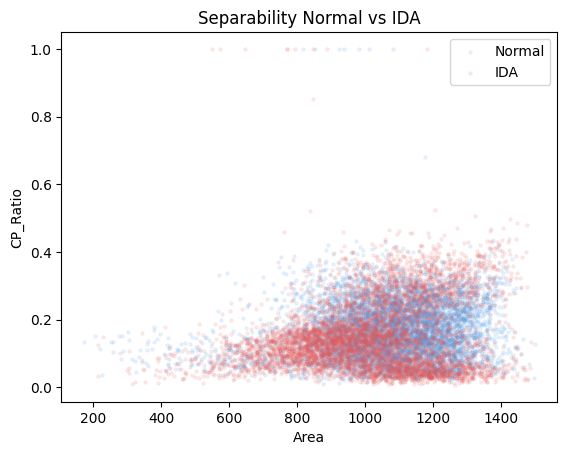

In [14]:
import matplotlib.pyplot as plt
for lbl, color, nama in [(0,'#4C9BE8','Normal'),(1,'#E85C5C','IDA')]:
    d = df_binary[df_binary['Cell_Label']==lbl]
    plt.scatter(d['Area'], d['CP_Ratio'], alpha=0.1, s=5, c=color, label=nama)
plt.xlabel('Area'); plt.ylabel('CP_Ratio')
plt.legend(); plt.title('Separability Normal vs IDA')
plt.show()